In [ ]:
import numpy as np

# --- Data and Constants from NIST/Research ---
R_kJ_molK = 8.314 / 1000  # kJ/(mol·K)
T_K = np.array([1358, 1511, 1639, 1791, 1964])
k_exp = np.array([4.37e-12, 7.60e-12, 6.50e-12, 8.70e-12, 1.20e-11])
ln_k_exp = np.log(k_exp)
lnA_const = -23.2255  # Fixed ln(A) from NIST linear fit [cite: 142, 335]

def f(Ea):
    """Derivative of SSE with respect to Ea: the root-finding target [cite: 151, 341]"""
    return np.sum(2 * (lnA_const - Ea / (R_kJ_molK * T_K) - ln_k_exp) * (-1 / (R_kJ_molK * T_K)))

def df(Ea):
    """Second derivative of SSE for Newton-Raphson quadratic convergence [cite: 156, 346]"""
    return np.sum(2 * (1 / (R_kJ_molK * T_K))**2)

# --- Newton-Raphson Trace ---
print("--- Newton-Raphson Iteration Log ---")
print(f"{'Iter':<5} | {'Ea (kJ/mol)':<15} | {'f(Ea)':<15}")
print("-" * 40)

Ea_nr = 0.03  # Initial anomalous guess [cite: 154, 344]
tol = 1e-6
for i in range(1, 11):
    f_val = f(Ea_nr)
    print(f"{i-1:<5} | {Ea_nr:<15.6f} | {f_val:<15.2e}")

    Ea_new = Ea_nr - f_val / df(Ea_nr)
    if abs(Ea_new - Ea_nr) < tol:
        print(f"{i:<5} | {Ea_new:<15.6f} | {f(Ea_new):<15.2e}")
        print(f"CONVERGED in {i} iterations.\n")
        break
    Ea_nr = Ea_new

# --- Bisection Trace ---
print("--- Bisection Method Iteration Log ---")
print(f"{'Iter':<5} | {'Lower (a)':<12} | {'Upper (b)':<12} | {'Midpoint (c)':<12}")
print("-" * 50)

a, b = 30.0, 40.0  # Corrected physical range [cite: 159, 160, 351]
for i in range(1, 100):
    c = (a + b) / 2
    print(f"{i:<5} | {a:<12.6f} | {b:<12.6f} | {c:<12.6f}")

    if (b - a) / 2 < tol:
        print(f"\nCONVERGED in {i} iterations.")
        print(f"Final Ea: {c:.6f} kJ/mol")
        break

    if f(a) * f(c) < 0:
        b = c
    else:
        a = c

--- Newton-Raphson Iteration Log ---
Iter  | Ea (kJ/mol)     | f(Ea)          
----------------------------------------
0     | 0.030000        | -1.80e+00      
1     | 32.448712       | -7.29e-17      
2     | 32.448712       | -7.29e-17      
CONVERGED in 2 iterations.

--- Bisection Method Iteration Log ---
Iter  | Lower (a)    | Upper (b)    | Midpoint (c)
--------------------------------------------------
1     | 30.000000    | 40.000000    | 35.000000   
2     | 30.000000    | 35.000000    | 32.500000   
3     | 30.000000    | 32.500000    | 31.250000   
4     | 31.250000    | 32.500000    | 31.875000   
5     | 31.875000    | 32.500000    | 32.187500   
6     | 32.187500    | 32.500000    | 32.343750   
7     | 32.343750    | 32.500000    | 32.421875   
8     | 32.421875    | 32.500000    | 32.460938   
9     | 32.421875    | 32.460938    | 32.441406   
10    | 32.441406    | 32.460938    | 32.451172   
11    | 32.441406    | 32.451172    | 32.446289   
12    | 32.446289    | 3

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# Konstanta
R_J_molK = 8.314  # Konstanta gas ideal dalam J/(mol·K)
R_kJ_molK = R_J_molK / 1000  # Konstanta gas ideal dalam kJ/(mol·K)
NA = 6.022e23  # Bilangan Avogadro

# Data Eksperimental NIST (hanya sampel)
T_K = np.array([1358, 1511, 1639, 1791, 1964])  # Temperatur (K)
# k (cm³/molecule s)
k_cm3_mol_s = np.array([4.37e-12, 7.60e-12, 6.50e-12, 8.70e-12, 1.20e-11])

# Transformasi data untuk plot Arrhenius: ln(k) vs 1/T
X = 1000 / T_K  # 1000/T (K⁻¹)
Y = np.log(k_cm3_mol_s) # ln(k)

In [ ]:
def arrhenius_linier(X, lnA, Ea_div_R):
    """Fungsi Arrhenius yang dilinierkan: Y = lnA - (Ea/R) * X"""
    return lnA - Ea_div_R * X

# Lakukan fitting kurva (Regresi Linier)
popt, pcov = curve_fit(arrhenius_linier, X, Y)

# Ekstraksi parameter
lnA_linier = popt[0]
Ea_div_R_linier = popt[1]

A_linier = np.exp(lnA_linier)
Ea_linier_kJ = Ea_div_R_linier * R_kJ_molK * 1000 / 1000 # konversi dari (Ea/R) * 1000 menjadi Ea (kJ/mol)

print("--- Hasil Regresi Linier (Metode Standar) ---")
print(f"ln(A) (lnA_linier): {lnA_linier:.4f}")
print(f"A (cm³/molecule s): {A_linier:.2e}")
print(f"Ea/R (K): {Ea_div_R_linier:.2f}")
print(f"Ea (kJ/mol): {Ea_linier_kJ:.2f}")
print("-------------------------------------------\n")

# Hasilnya akan digunakan sebagai tebakan awal.
A_initial = A_linier
Ea_initial = Ea_linier_kJ

--- Hasil Regresi Linier (Metode Standar) ---
ln(A) (lnA_linier): -23.2255
A (cm³/molecule s): 8.19e-11
Ea/R (K): 3.90
Ea (kJ/mol): 0.03
-------------------------------------------



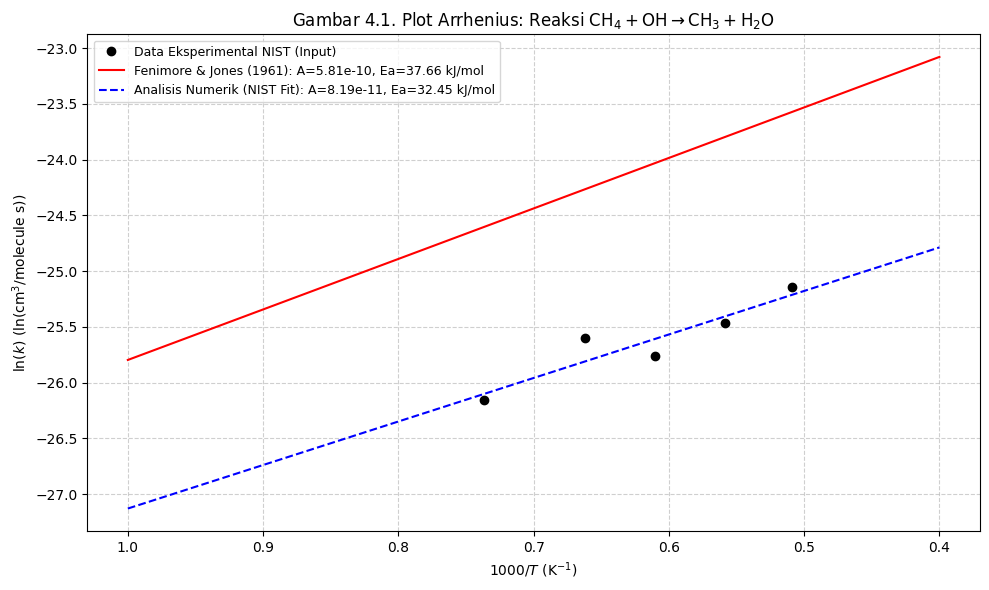

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Konstanta dan Data Eksperimental ---

# Konstanta Gas Ideal (diperlukan untuk perhitungan laju)
R_J_molK = 8.314  # J/(mol·K)
R_kJ_molK = R_J_molK / 1000  # kJ/(mol·K)

# Data Eksperimental NIST (Sampel data yang digunakan untuk fitting)
# Catatan: Data ini diasumsikan sebagai data input yang menghasilkan output numerik Anda.
T_K_eks = np.array([1358, 1511, 1639, 1791, 1964])  # K
# Data k (cm³/molecule s) (Nilai ln(k) yang sesuai dengan T)
k_eks = np.array([4.37e-12, 7.60e-12, 6.50e-12, 8.70e-12, 1.20e-11])

# Transformasi data untuk plot Arrhenius: ln(k) vs 1/T
X_eks = 1000 / T_K_eks  # 1000/T (K⁻¹)
Y_eks = np.log(k_eks) # ln(k)

# Rentang Temperatur untuk Garis Plot Model (dari 1000 K sampai 2500 K)
T_plot = np.linspace(1000, 2500, 100)
X_plot = 1000 / T_plot

# --- 2. Parameter Model ---

# 2.1. Fenimore & Jones (1961) - Model Referensi
A_FJ = 5.81e-10  # cm³/molecule s
Ea_FJ_kJ = 37.66  # kJ/mol

# 2.2. Analisis Numerik (NIST Fit) - Hasil Validasi Newton-Raphson/Bisection
A_NIST = 8.19e-11 # cm³/molecule s (Dari ln(A) = -23.2255)
Ea_NIST_kJ = 32.45 # kJ/mol

# --- 3. Fungsi Perhitungan Laju Reaksi ---

def arrhenius_rate(A, Ea_kJ, T):
    """
    Menghitung laju reaksi k menggunakan persamaan Arrhenius.
    k = A * exp(-Ea / (R*T))
    """
    # Ea harus dalam J (dikali 1000) agar sesuai dengan R (8.314 J/mol.K)
    return A * np.exp(-Ea_kJ * 1000 / (R_J_molK * T))

# Menghitung ln(k) untuk Garis Plot

# Model Fenimore & Jones
ln_k_FJ = np.log(arrhenius_rate(A_FJ, Ea_FJ_kJ, T_plot))
# Model Analisis Numerik
ln_k_NIST = np.log(arrhenius_rate(A_NIST, Ea_NIST_kJ, T_plot))

# --- 4. Plotting (Diagram Arrhenius) ---

plt.figure(figsize=(10, 6))

# Plot Data Eksperimental (Titik-titik Hitam)
plt.plot(X_eks, Y_eks, 'o', color='black', label='Data Eksperimental NIST (Input)')

# Plot Model Fenimore & Jones (Garis Merah)
label_FJ = f'Fenimore & Jones (1961): A={A_FJ:.2e}, Ea={Ea_FJ_kJ:.2f} kJ/mol'
plt.plot(X_plot, ln_k_FJ, '-', color='red', label=label_FJ)

# Plot Model Analisis Numerik (Garis Biru)
label_NIST = f'Analisis Numerik (NIST Fit): A={A_NIST:.2e}, Ea={Ea_NIST_kJ:.2f} kJ/mol'
plt.plot(X_plot, ln_k_NIST, '--', color='blue', label=label_NIST)

# Label dan Judul
plt.title(r'Gambar 4.1. Plot Arrhenius: Reaksi $\text{CH}_4 + \text{OH} \rightarrow \text{CH}_3 + \text{H}_2\text{O}$')
plt.xlabel(r'$1000/T \ (\text{K}^{-1})$')
plt.ylabel(r'$\ln(k) \ (\ln(\text{cm}^3/\text{molecule s}))$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=9)

# Membalik sumbu X agar Temperatur (T) naik ke kanan
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()